# Clasificador SVM Clásico

Clasificación binaria sobre el dataset Iris usando una Máquina de Vectores de Soporte (SVM) con kernel RBF.

Este notebook es la línea base clásica para el experimento `quantum_kernel`.  
Los resultados se guardan en `svm_results.json` para su uso en `comparison/comparison.ipynb`.

**Variable de configuración:** `N_FEATURES` controla cuántas características se usan (2 o 4).  
Para la versión de 4 características, los resultados se guardan automáticamente en `svm_results_4f.json`.

## Importaciones

In [1]:
import time
import json
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

## Configuración

In [ ]:
N_FEATURES  = 2          # 2 or 4
TEST_SIZE   = 0.2        # fraction of data held out for testing
RANDOM_SEED = 42         # reproducibility

RESULTS_FILE = "svm_results.json" if N_FEATURES == 2 else "svm_results_4f.json"

print(f"Configuration: N_FEATURES={N_FEATURES}, TEST_SIZE={TEST_SIZE}")
print(f"Results will be saved to: {RESULTS_FILE}")


## Dataset

Se usa el dataset Iris restringido a **2 clases** (Versicolor vs Virginica, clases 1 y 2).  
La clase 0 (Setosa) se descarta porque es linealmente separable y trivialmente fácil.

Características usadas:
- `N_FEATURES = 2`: longitud y anchura del pétalo (par más discriminativo)
- `N_FEATURES = 4`: las cuatro características

Todas las características se escalan a [0, 1] con `MinMaxScaler`. El notebook de kernel cuántico
aplica el mismo escalado para que ambos modelos reciban entradas idénticas.

In [3]:
iris = load_iris()

mask     = iris.target != 0
X_full   = iris.data[mask]
y_full   = iris.target[mask] - 1

if N_FEATURES == 2:
    X = X_full[:, 2:4]
    feature_names = ["petal length", "petal width"]
else:
    X = X_full
    feature_names = list(iris.feature_names)

scaler   = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_full, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y_full
)

print(f"Total samples : {len(X_scaled)}")
print(f"Train samples : {len(X_train)}")
print(f"Test samples  : {len(X_test)}")
print(f"Features used : {feature_names}")
print(f"Class balance (train): {np.bincount(y_train)}")

Total samples : 100
Train samples : 80
Test samples  : 20
Features used : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Class balance (train): [40 40]


## Algoritmo Clásico — SVM con Kernel RBF

Una Máquina de Vectores de Soporte encuentra el hiperplano que maximiza el margen entre clases.
El kernel RBF proyecta la entrada en un espacio de características de dimensión infinita, permitiendo
fronteras de decisión no lineales.

Este es el contraparte clásico directo del Kernel SVM Cuántico: ambos usan el mismo marco SVM;
la única diferencia es cómo se calcula la matriz del kernel — clásicamente mediante la fórmula RBF,
o mediante productos internos en un espacio de características cuántico.

In [ ]:
def train_svm(X_train, y_train):
    """Train an SVM with RBF kernel. Returns the fitted model and elapsed training time."""
    model = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_SEED)
    t0    = time.perf_counter()
    model.fit(X_train, y_train)
    elapsed = time.perf_counter() - t0
    return model, elapsed


def evaluate_model(model, X_train, y_train, X_test, y_test, X_scaled, y_full):
    """Evaluate the model and return a metrics dict."""
    y_pred_test  = model.predict(X_test)
    y_pred_train = model.predict(X_train)

    acc_test  = accuracy_score(y_test,  y_pred_test)
    acc_train = accuracy_score(y_train, y_pred_train)

    cv_scores = cross_val_score(model, X_scaled, y_full, cv=5, scoring="accuracy")

    return {
        "accuracy_test"  : float(acc_test),
        "accuracy_train" : float(acc_train),
        "cv_mean"        : float(cv_scores.mean()),
        "cv_std"         : float(cv_scores.std()),
        "cv_scores"      : cv_scores.tolist(),
        "y_pred_test"    : y_pred_test.tolist(),
        "y_test"         : y_test.tolist(),
    }

## Ejecución

In [ ]:
svm_model, train_time = train_svm(X_train, y_train)
metrics               = evaluate_model(svm_model, X_train, y_train, X_test, y_test, X_scaled, y_full)

print(f"Training time : {train_time:.4f} s")
print(f"Test accuracy : {metrics['accuracy_test']:.4f}")
print(f"Train accuracy: {metrics['accuracy_train']:.4f}")
print(f"CV accuracy   : {metrics['cv_mean']:.4f} ± {metrics['cv_std']:.4f}")
print()
print(classification_report(metrics['y_test'], metrics['y_pred_test'],
                             target_names=["Versicolor", "Virginica"]))

## Gráficas

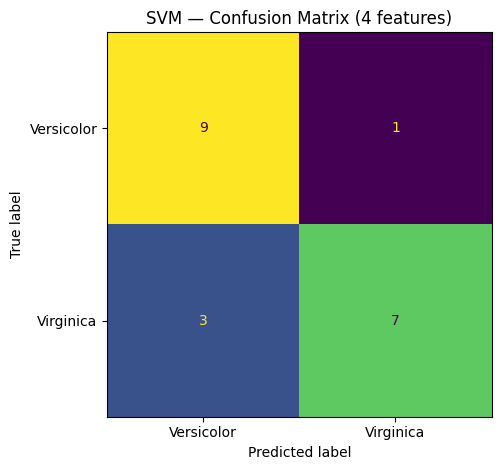

In [6]:
# --- Confusion matrix ---
cm   = confusion_matrix(metrics['y_test'], metrics['y_pred_test'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Versicolor", "Virginica"])
disp.plot(colorbar=False)
plt.title(f"SVM — Matriz de confusión ({N_FEATURES} características)")
plt.tight_layout()
plt.savefig(f"svm_confusion_matrix{'_4f' if N_FEATURES == 4 else ''}.png", dpi=150)
plt.show()

In [7]:
# --- Decision boundary (only for 2 features) ---
if N_FEATURES == 2:
    h = 0.005
    xx, yy = np.meshgrid(np.arange(0, 1 + h, h), np.arange(0, 1 + h, h))
    Z = svm_model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
    scatter = plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_full,
                          cmap="coolwarm", edgecolors="k", s=40)
    plt.colorbar(scatter, ticks=[0, 1], label="Clase")
    _es = {
        "petal length"     : "longitud del pétalo",
        "petal width"      : "anchura del pétalo",
        "sepal length (cm)": "longitud del sépalo (cm)",
        "sepal width (cm)" : "anchura del sépalo (cm)",
        "petal length (cm)": "longitud del pétalo (cm)",
        "petal width (cm)" : "anchura del pétalo (cm)",
    }
    plt.xlabel(_es.get(feature_names[0], feature_names[0]))
    plt.ylabel(_es.get(feature_names[1], feature_names[1]))
    plt.title("SVM — Frontera de decisión (2 características)")
    plt.tight_layout()
    plt.savefig("svm_decision_boundary.png", dpi=150)
    plt.show()
else:
    print("Decision boundary plot skipped (only available for N_FEATURES=2).")

Decision boundary plot skipped (only available for N_FEATURES=2).


## Guardar Resultados

In [8]:
results = {
    "model"             : "SVM-RBF",
    "n_features"        : N_FEATURES,
    "feature_names"     : feature_names,
    "n_train"           : int(len(X_train)),
    "n_test"            : int(len(X_test)),
    "random_seed"       : RANDOM_SEED,
    "train_time_s"      : float(train_time),
    "accuracy_test"     : metrics["accuracy_test"],
    "accuracy_train"    : metrics["accuracy_train"],
    "cv_mean"           : metrics["cv_mean"],
    "cv_std"            : metrics["cv_std"],
    "cv_scores"         : metrics["cv_scores"],
    "y_test"            : metrics["y_test"],
    "y_pred_test"       : metrics["y_pred_test"],
    "n_support_vectors" : int(sum(svm_model.n_support_)),
    "svm_C"             : svm_model.C,
    "svm_gamma"         : svm_model.gamma,
}

with open(RESULTS_FILE, "w") as f:
    json.dump(results, f, indent=2)

print(f"Results saved to {RESULTS_FILE}")
print(json.dumps({k: v for k, v in results.items()
                  if k not in ("cv_scores", "y_test", "y_pred_test")}, indent=2))

Results saved to svm_results_4f.json
{
  "model": "SVM-RBF",
  "n_features": 4,
  "feature_names": [
    "sepal length (cm)",
    "sepal width (cm)",
    "petal length (cm)",
    "petal width (cm)"
  ],
  "n_train": 80,
  "n_test": 20,
  "random_seed": 42,
  "train_time_s": 0.0014869579990772763,
  "accuracy_test": 0.8,
  "accuracy_train": 0.9625,
  "cv_mean": 0.9400000000000001,
  "cv_std": 0.05830951894845301,
  "n_support_vectors": 22,
  "svm_C": 1.0,
  "svm_gamma": "scale"
}
